# Model Evaluation — all stages

Benchmarks several ML algorithms on each pipeline stage (`url`, `domain`, `content`) using
labeled data from MongoDB.

**Key design choice:** features are produced by the engine's *own* extractors via
`collect_training_data`, so what we evaluate here is exactly what the deployed pipeline
trains and predicts on — same feature math, same alignment to each stage's
`feature_columns`, and the same per-domain deduplication for the `domain` stage
(one row per domain snapshot, labeled *phish* if any of its URLs is phish).

**Prerequisites**
- MongoDB running with collected, labeled data (`python -m phishing_engine.cli.collect ...`).
- Run this notebook with the project's `.venv` as the kernel (so `phishing_engine`,
  `xgboost`, `lightgbm` resolve).
- Working directory = repo root (where `config/pipeline.json` lives).

In [16]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the project importable when the kernel's cwd is the repo root.
sys.path.insert(0, os.path.abspath("."))

import phishing_engine.stages  # noqa: F401  (registers url/domain/content stages)
from phishing_engine.core.config import load_config
from phishing_engine.core.registry import get_stage
from phishing_engine.core.training import collect_training_data
from phishing_engine.storage.mongo import MongoStore

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, auc, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
print("imports ok")

imports ok


## Parameters

In [17]:
CONFIG_PATH = "config/pipeline.json"
LIMIT = 0                    # cap labeled docs per stage (0 = all). Lower for a quick smoke run.
TEST_SIZE = 0.2
RS = 42                      # random_state, shared across split + models for reproducibility
POSITIVE_LABEL = "phish"     # encoded as 1; benign -> 0
INCLUDE_SLOW_MODELS = False  # SVM (RBF) fit is ~O(n^2) — enable only on small datasets
RUN_CROSS_VAL = False        # add 5-fold stratified CV F1 (re-fits each model; slower)
STAGES = ["url", "domain", "content"]

# --- Feature caching -----------------------------------------------------------
# Feature extraction (esp. content + domain) is the slow part. We cache each
# dataset to CSV under FEATURE_CACHE_DIR; later runs reuse it. Flip FORCE_RECALC
# when you've collected new data and want to regenerate.
FEATURE_CACHE_DIR = "feature_cache"
USE_FEATURE_CACHE = True
FORCE_RECALC = False


## Feature cache helpers

CSV files written under `FEATURE_CACHE_DIR/` so subsequent notebook runs skip the
expensive feature extraction. Filenames embed `LIMIT` when it's non-zero so changing
the cap doesn't silently reuse a smaller cached version. The joint set stores three
aligned stage files plus a meta file with `_id` + `_label`.

In [18]:
import os

def _cache_path(name, limit=None):
    suffix = f"_lim{limit}" if limit else ""
    return os.path.join(FEATURE_CACHE_DIR, f"{name}{suffix}.csv")

def _cache_hit(path):
    return USE_FEATURE_CACHE and not FORCE_RECALC and os.path.exists(path)

def _save_single(path, X, labels, keys=None):
    os.makedirs(FEATURE_CACHE_DIR, exist_ok=True)
    out = X.copy()
    out["_label"] = labels
    if keys is not None:              # join key (url _id, or domain_record_ref for domain)
        out["_key"] = keys
    out.to_csv(path, index=False)

def _load_single(path):
    out = pd.read_csv(path)
    labels = out.pop("_label").tolist()
    # _key is absent in caches written before the joint-reuse change; treat as unjoinable.
    keys = out.pop("_key").tolist() if "_key" in out.columns else None
    y = np.array([1 if lab == POSITIVE_LABEL else 0 for lab in labels])
    return out, y, keys

def _save_joint(meta_path, paths, ids, labels, dfs):
    os.makedirs(FEATURE_CACHE_DIR, exist_ok=True)
    pd.DataFrame({"_id": ids, "_label": labels}).to_csv(meta_path, index=False)
    for p, df in zip(paths, dfs):
        df.to_csv(p, index=False)

def _load_joint(meta_path, paths):
    meta = pd.read_csv(meta_path)
    ids = meta["_id"].tolist()
    y = np.array([1 if lab == POSITIVE_LABEL else 0 for lab in meta["_label"]])
    dfs = [pd.read_csv(p) for p in paths]
    return dfs[0], dfs[1], dfs[2], y, ids

def clear_feature_cache():
    """Remove every cached CSV under FEATURE_CACHE_DIR."""
    if not os.path.isdir(FEATURE_CACHE_DIR):
        print("nothing to clear"); return
    n = 0
    for f in os.listdir(FEATURE_CACHE_DIR):
        if f.endswith(".csv"):
            os.remove(os.path.join(FEATURE_CACHE_DIR, f)); n += 1
    print(f"cleared {n} cached file(s) from {FEATURE_CACHE_DIR}/")

## Connect to MongoDB and inspect available data

In [19]:
config = load_config(CONFIG_PATH)
mongo = config.pipeline.mongo
STAGE_CONFIGS = {s.id: s for s in config.pipeline.stages}
store = MongoStore(mongo.uri, mongo.database, mongo.collection, mongo.domain_collection)

print(f"db={mongo.database!r}  urls={mongo.collection!r}  domains={mongo.domain_collection!r}\n")
for sid in STAGES:
    stage = get_stage(sid)(STAGE_CONFIGS[sid], None)
    n = store.count_labeled(require=stage.requires_raw)
    note = " (rows deduped to one per domain at extraction)" if stage.requires_raw == "domain_record" else ""
    print(f"  {sid:8} requires_raw={str(stage.requires_raw):14} labeled docs={n}{note}")

db='phishing_engine'  urls='url_documents'  domains='domain_records'

  url      requires_raw=None           labeled docs=8073
  domain   requires_raw=domain_record  labeled docs=8071 (rows deduped to one per domain at extraction)
  content  requires_raw=content        labeled docs=7605


## Build a feature matrix for a stage

Runs the stage's extractor over every eligible labeled document (same path as training),
aligns to the configured `feature_columns` when present, coerces everything to numeric,
and encodes the label as `phish=1 / benign=0`.

In [20]:
def build_dataset(stage_id, limit=LIMIT):
    cache = _cache_path(f"{stage_id}_dataset", limit if limit else None)
    if _cache_hit(cache):
        X, y, _keys = _load_single(cache)
        if len(np.unique(y)) < 2:
            raise ValueError(f"Cached dataset for '{stage_id}' has only one class; "
                             f"set FORCE_RECALC=True to rebuild.")
        print(f"[cache] loaded {stage_id}: {X.shape[0]} rows x {X.shape[1]} feats  ({cache})")
        return X, y

    stage_config = STAGE_CONFIGS[stage_id]
    stage = get_stage(stage_id)(stage_config, None)

    rows, labels = collect_training_data(stage, store, limit=limit)
    if not rows:
        raise ValueError(f"No labeled training rows for stage '{stage_id}' "
                         f"(requires_raw={stage.requires_raw}). Collect data first.")

    df = pd.DataFrame(rows)
    fcols = stage_config.feature_columns
    if fcols:                       # pin to the model's expected column set/order
        for c in fcols:
            if c not in df.columns:
                df[c] = 0
        df = df[fcols]
    df = df.replace({True: 1, False: 0})
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    y = np.array([1 if lab == POSITIVE_LABEL else 0 for lab in labels])
    if len(np.unique(y)) < 2:
        raise ValueError(f"Stage '{stage_id}' has only one class present: cannot evaluate.")

    if USE_FEATURE_CACHE:
        _save_single(cache, df, labels)
        print(f"[cache] saved {stage_id}: {df.shape[0]} rows -> {cache}")
    return df, y

## Model zoo

In [21]:
def make_models():
    models = {
        "Logistic Regression": Pipeline([("scaler", StandardScaler()),
                                         ("clf", LogisticRegression(max_iter=1000, random_state=RS))]),
        "Decision Tree": DecisionTreeClassifier(random_state=RS),
        "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RS),
        "Extra Trees": ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=RS),
        "Gradient Boosting": GradientBoostingClassifier(random_state=RS),
        "KNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        "XGBoost": XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                                 subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
                                 tree_method="hist", n_jobs=-1, random_state=RS),
        "LightGBM": LGBMClassifier(n_estimators=400, learning_rate=0.05, n_jobs=-1,
                                   random_state=RS, verbose=-1),
    }
    if INCLUDE_SLOW_MODELS:
        models["SVM (RBF)"] = Pipeline([("scaler", StandardScaler()),
                                        ("clf", SVC(kernel="rbf", probability=True, random_state=RS))])
    return models

## Evaluation

Single stratified holdout split per stage. Every model is fit on the train split and
scored on the held-out test split (accuracy / precision / recall / F1 / ROC-AUC, with
*phish* as the positive class). Optionally adds 5-fold stratified CV F1.

In [22]:
def _scores(y_true, y_pred, proba):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, proba),
    }

def _proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        d = model.decision_function(X)
        return (d - d.min()) / (d.max() - d.min() + 1e-9)
    return model.predict(X).astype(float)

def evaluate_stage(X, y):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE,
                                              stratify=y, random_state=RS)
    rows, fitted, roc_data = [], {}, {}
    for name, model in make_models().items():
        t0 = time.perf_counter()
        try:
            model.fit(X_tr, y_tr)
        except Exception as e:
            print(f"  [skip] {name}: {e}")
            continue
        fit_s = time.perf_counter() - t0
        proba = _proba(model, X_te)
        row = {"model": name, **_scores(y_te, model.predict(X_te), proba), "fit_sec": fit_s}
        if RUN_CROSS_VAL:
            cv = cross_val_score(model, X, y, scoring="f1", n_jobs=-1,
                                 cv=StratifiedKFold(5, shuffle=True, random_state=RS))
            row["cv_f1_mean"], row["cv_f1_std"] = cv.mean(), cv.std()
        rows.append(row)
        fitted[name] = model
        roc_data[name] = (y_te, proba)
    res = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
    return res, fitted, roc_data, (X_te, y_te)

## Plotting helpers

In [23]:
def plot_metric_bars(res, title):
    metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    ax = res.set_index("model")[metrics].plot(kind="bar", figsize=(11, 5))
    ax.set_title(f"{title} — model comparison"); ax.set_ylim(0, 1)
    ax.legend(loc="lower right", ncol=5); ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

def plot_roc(roc_data, title):
    plt.figure(figsize=(7, 6))
    for name, (yt, pr) in roc_data.items():
        fpr, tpr, _ = roc_curve(yt, pr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
    plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
    plt.title(f"{title} — ROC"); plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout(); plt.show()

def plot_confusion(model, X_te, y_te, title):
    cm = confusion_matrix(y_te, model.predict(X_te))
    ConfusionMatrixDisplay(cm, display_labels=["benign", "phish"]).plot(cmap="Blues", colorbar=False)
    plt.title(title); plt.tight_layout(); plt.show()

## Run all stages

`ALL_RESULTS` accumulates each stage's comparison table, fitted models, ROC data, and
test split so the final summary cell can reach back into them.

In [24]:
ALL_RESULTS = {}

def run_stage(stage_id):
    print(f"===== Stage: {stage_id} =====")
    X, y = build_dataset(stage_id)
    print(f"feature matrix: {X.shape[0]} samples x {X.shape[1]} features | "
          f"phish={int(y.sum())}  benign={int((y == 0).sum())}\n")
    res, fitted, roc_data, (X_te, y_te) = evaluate_stage(X, y)
    ALL_RESULTS[stage_id] = {"results": res, "fitted": fitted,
                             "roc": roc_data, "test": (X_te, y_te)}
    num_cols = [c for c in res.columns if c != "model"]
    display(res.style.format("{:.4f}", subset=num_cols)
                     .background_gradient(subset=["f1"], cmap="Greens"))
    plot_metric_bars(res, stage_id)
    plot_roc(roc_data, stage_id)
    best = res.iloc[0]["model"]
    print(f"best by F1: {best}")
    plot_confusion(fitted[best], X_te, y_te, f"{stage_id} — {best}")
    print(classification_report(y_te, fitted[best].predict(X_te),
                                target_names=["benign", "phish"]))
    return res

### URL stage

===== Stage: url =====
[cache] loaded url: 8073 rows x 39 feats  (feature_cache/url_dataset.csv)
feature matrix: 8073 samples x 39 features | phish=2588  benign=5485



,model,accuracy,precision,recall,f1,roc_auc,fit_sec
0,Extra Trees,0.9765,0.9633,0.9633,0.9633,0.9945,0.8472
1,LightGBM,0.9765,0.9651,0.9614,0.9632,0.9968,0.4775
2,XGBoost,0.9752,0.9596,0.9633,0.9615,0.9963,0.5023
3,Random Forest,0.9746,0.9649,0.9556,0.9602,0.9950,1.1767
4,Gradient Boosting,0.9690,0.9625,0.9402,0.9512,0.9945,1.1865
5,KNN,0.9604,0.9558,0.9189,0.9370,0.9847,0.0174
6,Decision Tree,0.9548,0.9238,0.9363,0.9300,0.9512,0.0440
7,Logistic Regression,0.9542,0.9387,0.9170,0.9277,0.9886,0.1997


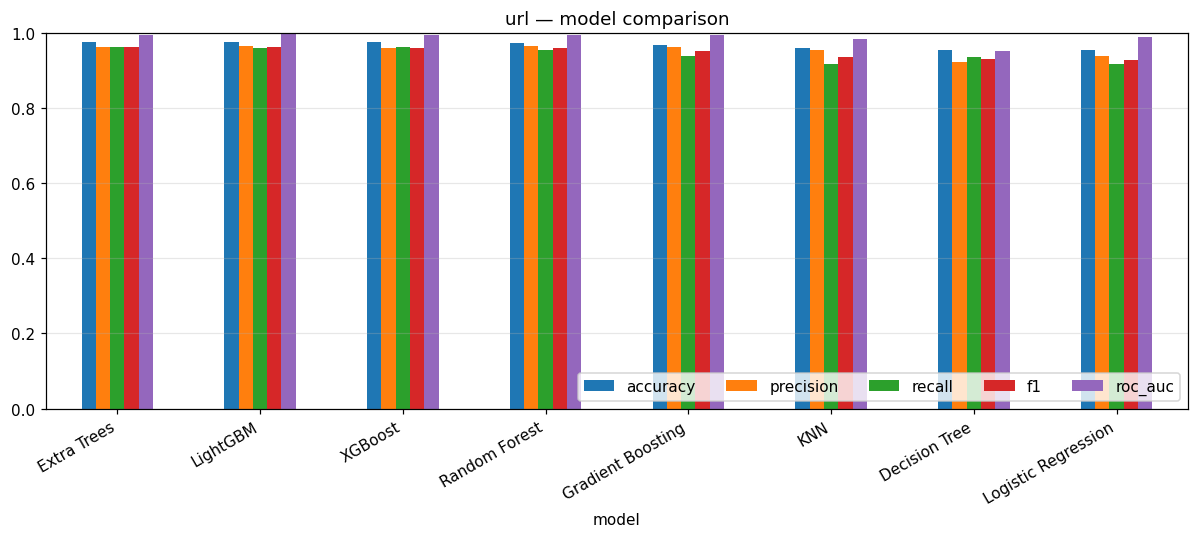

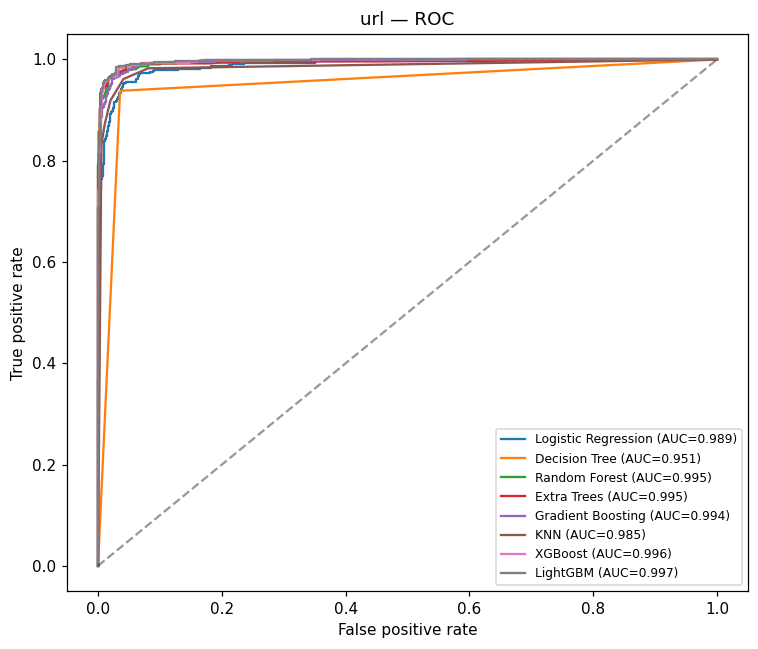

best by F1: Extra Trees


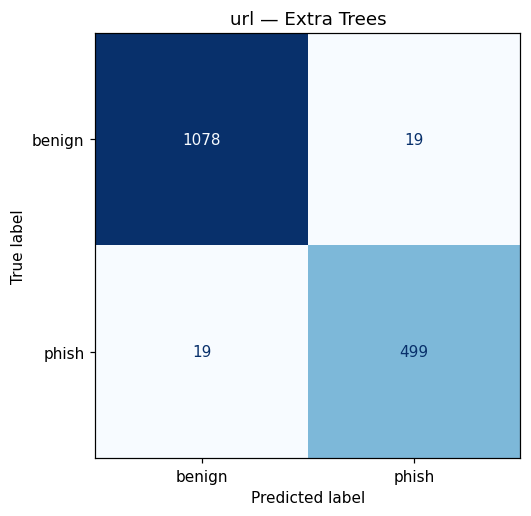

              precision    recall  f1-score   support

      benign       0.98      0.98      0.98      1097
       phish       0.96      0.96      0.96       518

    accuracy                           0.98      1615
   macro avg       0.97      0.97      0.97      1615
weighted avg       0.98      0.98      0.98      1615



In [25]:
try:
    run_stage("url")
except Exception as e:
    print("url stage skipped:", e)

### Domain stage

===== Stage: domain =====
[cache] loaded domain: 4609 rows x 136 feats  (feature_cache/domain_dataset.csv)
feature matrix: 4609 samples x 136 features | phish=2027  benign=2582



,model,accuracy,precision,recall,f1,roc_auc,fit_sec
0,XGBoost,0.9740,0.9847,0.9556,0.9699,0.9949,0.9002
1,LightGBM,0.9707,0.9871,0.9457,0.9660,0.9942,0.8380
2,Gradient Boosting,0.9675,0.9795,0.9457,0.9623,0.9922,2.3772
3,Random Forest,0.9653,0.9869,0.9333,0.9594,0.9909,1.0265
4,Extra Trees,0.9512,0.9787,0.9086,0.9424,0.9884,0.7836
5,Logistic Regression,0.9425,0.9490,0.9185,0.9335,0.9769,1.5755
6,Decision Tree,0.9371,0.9242,0.9333,0.9287,0.9367,0.1784
7,KNN,0.9252,0.9444,0.8815,0.9119,0.9659,0.0130


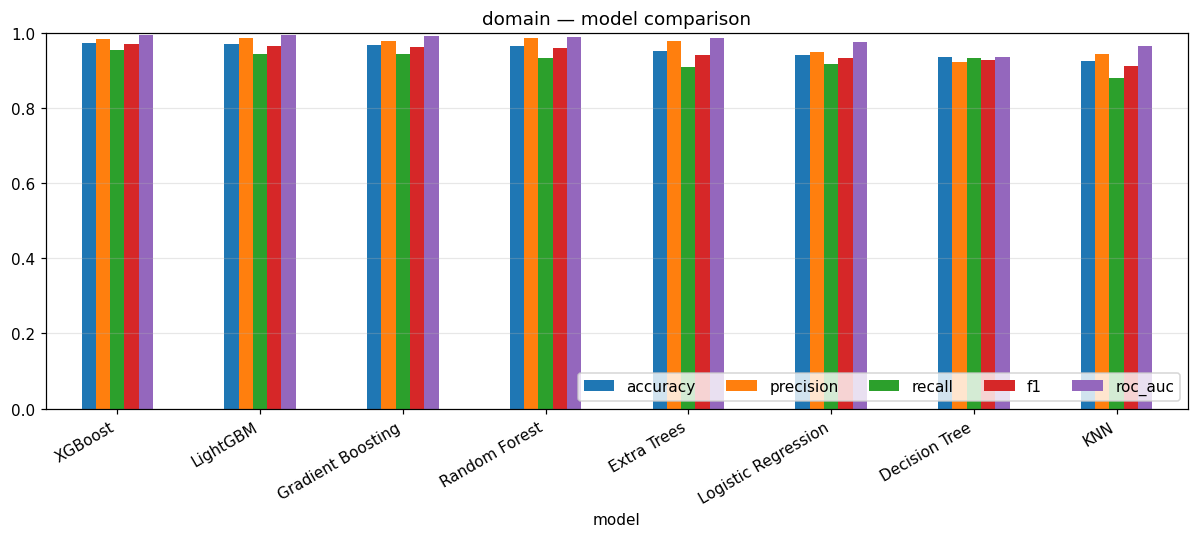

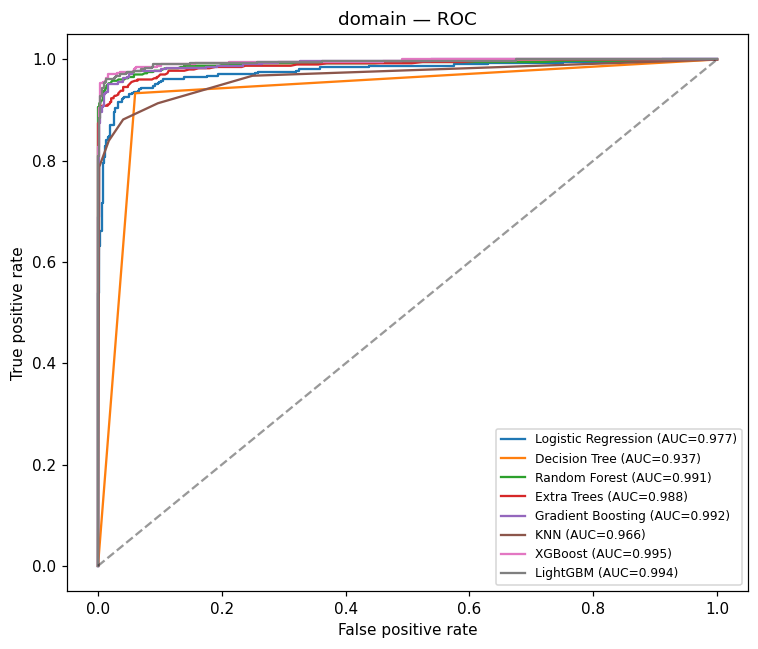

best by F1: XGBoost


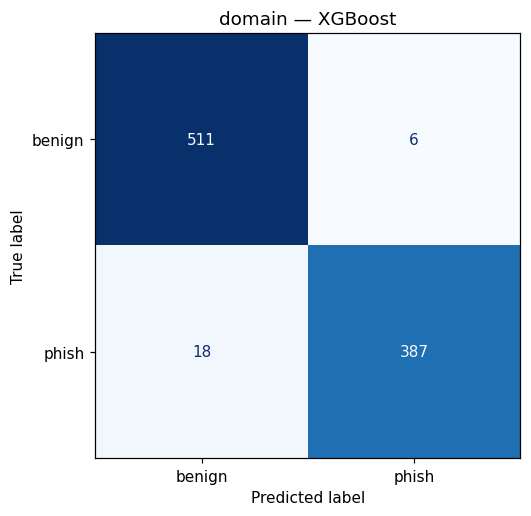

              precision    recall  f1-score   support

      benign       0.97      0.99      0.98       517
       phish       0.98      0.96      0.97       405

    accuracy                           0.97       922
   macro avg       0.98      0.97      0.97       922
weighted avg       0.97      0.97      0.97       922



In [26]:
try:
    run_stage("domain")
except Exception as e:
    print("domain stage skipped:", e)

### Content stage

===== Stage: content =====
[cache] loaded content: 7605 rows x 111 feats  (feature_cache/content_dataset.csv)
feature matrix: 7605 samples x 111 features | phish=2303  benign=5302



,model,accuracy,precision,recall,f1,roc_auc,fit_sec
0,LightGBM,0.9750,0.9732,0.9436,0.9581,0.9932,0.7207
1,Random Forest,0.9744,0.9689,0.9458,0.9572,0.9949,1.0351
2,XGBoost,0.9730,0.9667,0.9436,0.9550,0.9925,0.7307
3,Extra Trees,0.9730,0.9773,0.9328,0.9545,0.9940,0.7799
4,Gradient Boosting,0.9573,0.9267,0.9328,0.9297,0.9855,2.8192
5,Decision Tree,0.9533,0.9149,0.9328,0.9237,0.9503,0.1915
6,KNN,0.9461,0.9183,0.9024,0.9103,0.9746,0.0190
7,Logistic Regression,0.8988,0.8152,0.8612,0.8376,0.9524,1.2094


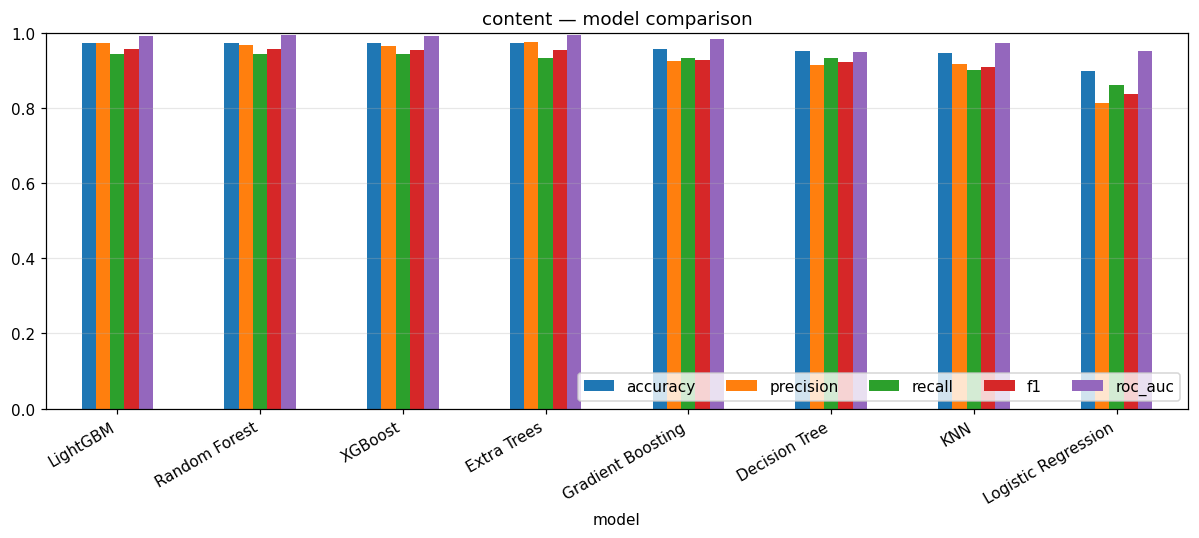

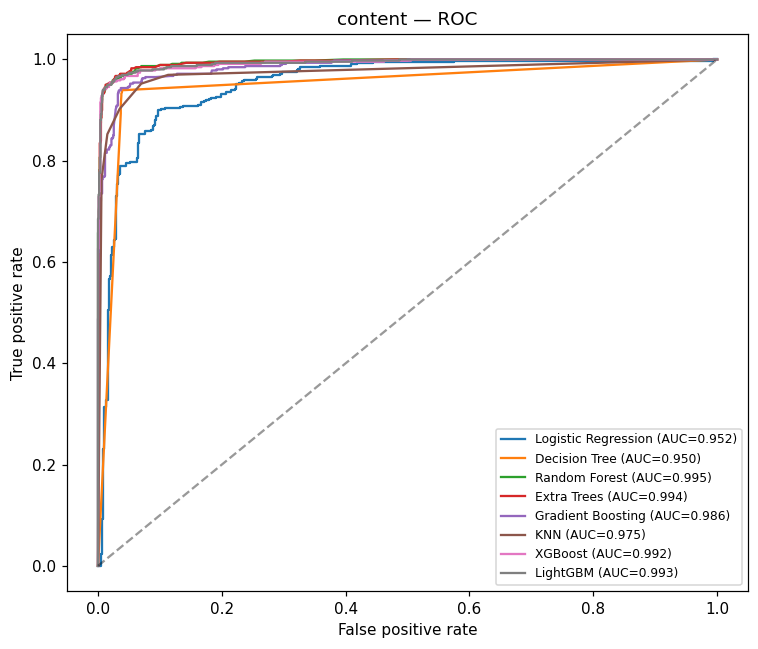

best by F1: LightGBM


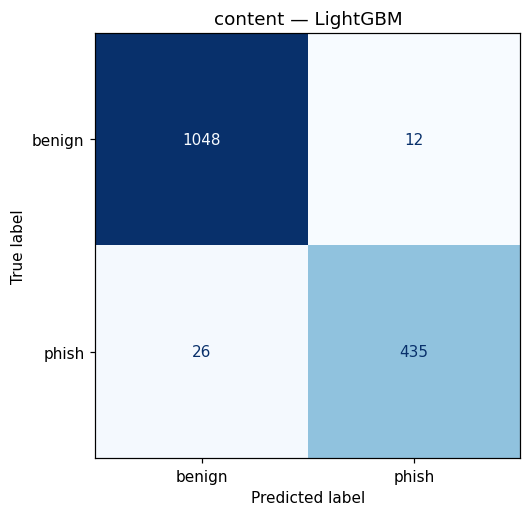

              precision    recall  f1-score   support

      benign       0.98      0.99      0.98      1060
       phish       0.97      0.94      0.96       461

    accuracy                           0.98      1521
   macro avg       0.97      0.97      0.97      1521
weighted avg       0.97      0.98      0.97      1521



In [27]:
try:
    run_stage("content")
except Exception as e:
    print("content stage skipped:", e)

## Combined summary — best model per stage

In [28]:
summary = []
for sid, r in ALL_RESULTS.items():
    top = r["results"].iloc[0]
    summary.append({"stage": sid, "best_model": top["model"],
                    "f1": top["f1"], "roc_auc": top["roc_auc"],
                    "precision": top["precision"], "recall": top["recall"],
                    "accuracy": top["accuracy"]})
if not summary:
    print("No stages evaluated yet — run the stage cells above.")
summary_df = pd.DataFrame(summary).set_index("stage") if summary else pd.DataFrame()
summary_df

,best_model,f1,roc_auc,precision,recall,accuracy
stage,,,,,,
url,Extra Trees,0.963320,0.994520,0.963320,0.963320,0.976471
domain,XGBoost,0.969925,0.994942,0.984733,0.955556,0.973970
content,LightGBM,0.958150,0.993221,0.973154,0.943601,0.975016


## (Optional) Save comparison tables to disk

Uncomment to write one CSV per stage under `eval_results/`.

In [29]:
# os.makedirs("eval_results", exist_ok=True)
# for sid, r in ALL_RESULTS.items():
#     r["results"].to_csv(f"eval_results/{sid}_model_comparison.csv", index=False)
# print("saved to eval_results/")

## Close the MongoDB connection

In [30]:
store.close()
print('done')

done
